# Movies Revenue and Ratings Prediction: Modeling

Two predictive tasks based on the cleaned TMDB dataset (2010–2024) from the EDA notebook:

  **Task A (Regression):** predict `log_revenue` from pre-release features.
  
  **Task B (Classification):** predict `high_rating` = 1 if `tmdb_vote_average >= 7.0`.

In [ ]:
#Imports
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             roc_auc_score, accuracy_score, f1_score,
                             precision_recall_curve, roc_curve, confusion_matrix)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
sns.set_theme(style='whitegrid')
os.makedirs('model_outputs', exist_ok=True)

In [ ]:
#Load cleaned data (from EDA notebook)
CLEAN_PATH = 'data/clean_movies.pkl'
df = pd.read_pickle(CLEAN_PATH)
print('Loaded:', df.shape)
df.head(2)

Loaded: (3532, 47)


,movie_id,imdb_id,title,release_date,runtime,budget,revenue,original_language,popularity,tmdb_vote_average,tmdb_vote_count,adult,status,overview,tagline,genres,production_companies,production_countries,keywords,cast_names,cast_popularities,num_cast,director_names,director_popularities,release_year,release_month,release_quarter,release_dayofweek,is_summer_release,is_holiday_season_release,log_revenue,log_budget,num_genres,num_production_companies,num_production_countries,is_us_production,is_international_coproduction,top_cast_popularity,top3_cast_avg_pop,top5_cast_avg_pop,max_cast_popularity,director_popularity,overview_length,tagline_length,has_tagline,num_keywords,high_rating
0,10193,tt0435761,Toy Story 3,2010-06-16,102,200000000,1067316101,en,15.3618,7.804,15655,False,Released,"Woody, Buzz, and the rest of Andy's toys haven...",No toy gets left behind.,"[Animation, Family, Comedy]",[Pixar],[US],"[escape, hostage, college, villain, sequel, bu...","[Tom Hanks, Tim Allen, Joan Cusack, Don Rickle...","[13.1439, 3.729, 3.0282, 2.5204, 3.368, 2.3112...",60,[Lee Unkrich],[1.0261],2010,6,2,2,1,0,20.788413,19.113828,3,1,1,1,0,13.1439,6.633700,5.15790,13.1439,1.0261,247,24,1,13,1
1,12155,tt1014759,Alice in Wonderland,2010-03-03,108,200000000,1025467110,en,10.7705,6.639,14742,False,Released,"Alice, now 19 years old, returns to the whimsi...",You're invited to a very important date.,"[Family, Fantasy, Adventure]","[Walt Disney Pictures, Roth Films, Team Todd, ...",[US],"[based on novel or book, queen, based on child...","[Mia Wasikowska, Johnny Depp, Anne Hathaway, H...","[2.1955, 7.283, 24.4937, 3.8135, 2.2826, 1.505...",58,[Tim Burton],[3.0735],2010,3,1,2,0,0,20.748414,19.113828,3,5,1,1,0,2.1955,11.324067,8.01366,24.4937,3.0735,139,40,1,18,0


## 1. Modeling feature

We use **pre-release** features only (no `popularity`, `tmdb_vote_count`, `tmdb_vote_average` for regression; and we exclude `revenue`-derived columns for classification). Multi-hot encodings are created for genres, top production companies, and top countries.

In [ ]:
#Build features
import ast
from collections import Counter

#for robustness and debugging
#Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ['_'.join([str(x) for x in c if x != '']) for c in df.columns]

#Ensure list-like columns are actual Python lists (not stringified)
def _to_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, str):
        s = x.strip()
        if s.startswith('[') and s.endswith(']'):
            try:
                v = ast.literal_eval(s)
                return list(v) if isinstance(v, (list, tuple)) else [v]
            except Exception:
                return [s] if s else []
        return [s] if s else []
    if x is None:
        return []
    try:
        if pd.isna(x):
            return []
    except Exception:
        pass
    return [x]

for col in ['genres', 'production_companies', 'production_countries']:
    df[col] = df[col].apply(_to_list)

TOP_N_COMPANIES = 20
TOP_N_COUNTRIES = 15

# Genres
all_genres = sorted({g for gs in df['genres'] for g in gs if isinstance(g, str)})
for g in all_genres:
    df[f'g_{g}'] = df['genres'].apply(lambda xs: int(g in xs))

# Top companies
comp_counter = Counter(c for cs in df['production_companies'] for c in cs if isinstance(c, str))
top_companies = [c for c, _ in comp_counter.most_common(TOP_N_COMPANIES)]
for c in top_companies:
    df[f'co_{c}'] = df['production_companies'].apply(lambda xs: int(c in xs))

# Top countries
country_counter = Counter(c for cs in df['production_countries'] for c in cs if isinstance(c, str))
top_countries = [c for c, _ in country_counter.most_common(TOP_N_COUNTRIES)]
for c in top_countries:
    df[f'ctry_{c}'] = df['production_countries'].apply(lambda xs: int(c in xs))

numeric_features = [
    'log_budget', 'runtime',
    'release_year', 'release_month', 'release_quarter', 'release_dayofweek',
    'is_summer_release', 'is_holiday_season_release',
    'num_genres', 'num_production_companies', 'num_production_countries',
    'is_us_production', 'is_international_coproduction',
    'top_cast_popularity', 'top3_cast_avg_pop', 'top5_cast_avg_pop',
    'max_cast_popularity', 'num_cast', 'director_popularity',
    'overview_length', 'tagline_length', 'has_tagline', 'num_keywords',
]
genre_features   = [f'g_{g}'  for g in all_genres]
company_features = [f'co_{c}' for c in top_companies]
country_features = [f'ctry_{c}' for c in top_countries]

#check
FEATURES = list(dict.fromkeys(numeric_features + genre_features + company_features + country_features))
print('Total features:', len(FEATURES))
print('df columns index type:', type(df.columns).__name__)

#remove duplicated columns if any
keep_cols = FEATURES + ['log_revenue', 'tmdb_vote_average', 'release_year', 'title', 'movie_id']
keep_cols = list(dict.fromkeys([c for c in keep_cols if c in df.columns]))
df_model = df[keep_cols].copy()
df_model = df_model.loc[:, ~df_model.columns.duplicated()].copy()
df_model = df_model.dropna(subset=FEATURES).copy()
df_model['high_rating'] = (df_model['tmdb_vote_average'] >= 7.0).astype(int)

print('Modeling shape:', df_model.shape)
print('Duplicated columns:', df_model.columns[df_model.columns.duplicated()].tolist())

Total features: 77
df columns index type: Index
Modeling shape: (3532, 82)
Duplicated columns: []


In [ ]:
#Time-based split
FEATURES = [f for f in FEATURES if f in df_model.columns]

train_mask = df_model['release_year'] <= 2021
val_mask   = df_model['release_year'] == 2022
test_mask  = df_model['release_year'] >= 2023

X_train = df_model[FEATURES].loc[train_mask].to_numpy()
X_val   = df_model[FEATURES].loc[val_mask].to_numpy()
X_test  = df_model[FEATURES].loc[test_mask].to_numpy()

y_reg_train = df_model.loc[train_mask, 'log_revenue'].to_numpy()
y_reg_val   = df_model.loc[val_mask,   'log_revenue'].to_numpy()
y_reg_test  = df_model.loc[test_mask,  'log_revenue'].to_numpy()

y_cls_train = df_model.loc[train_mask, 'high_rating'].to_numpy()
y_cls_val   = df_model.loc[val_mask,   'high_rating'].to_numpy()
y_cls_test  = df_model.loc[test_mask,  'high_rating'].to_numpy()

split_info = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'n': [len(y_reg_train), len(y_reg_val), len(y_reg_test)],
    'year_range': ['<=2021', '2022', '2023-2024'],
    'high_rating_ratio': [y_cls_train.mean(), y_cls_val.mean(), y_cls_test.mean()],
})
split_info

,split,n,year_range,high_rating_ratio
0,train,2976,<=2021,0.277554
1,val,166,2022,0.397590
2,test,390,2023-2024,0.341026


In [ ]:
#Pre-defined evaluation helpers
def eval_regression(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }

def eval_classification(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'ROC_AUC': roc_auc_score(y_true, y_prob),
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'PosRate': y_pred.mean(),
    }

## 2. Task A — Revenue regression

In [ ]:
#Regression models
reg_models = {
    'Baseline_Mean': DummyRegressor(strategy='mean'),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0, random_state=42))]),
    'RandomForest': RandomForestRegressor(n_estimators=400, max_depth=None, min_samples_leaf=2,
                                          n_jobs=-1, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=400, max_depth=3, learning_rate=0.05,
                                                  random_state=42),
}

reg_results = []
reg_fitted = {}
for name, m in reg_models.items():
    m.fit(X_train, y_reg_train)
    val_metrics  = eval_regression(y_reg_val,  m.predict(X_val))
    test_metrics = eval_regression(y_reg_test, m.predict(X_test))
    reg_results.append({'model': name,
                        **{f'val_{k}': v  for k, v in val_metrics.items()},
                        **{f'test_{k}': v for k, v in test_metrics.items()}})
    reg_fitted[name] = m

reg_df = pd.DataFrame(reg_results).sort_values('test_RMSE')
reg_df

,model,val_MAE,val_RMSE,val_R2,test_MAE,test_RMSE,test_R2
1,Ridge,1.088566,1.481528,0.535219,0.990630,1.255643,0.538316
3,GradientBoosting,1.259098,1.615358,0.447457,1.177945,1.469327,0.367808
2,RandomForest,1.272077,1.690262,0.395026,1.199054,1.527088,0.317125
0,Baseline_Mean,1.764033,2.186261,-0.012122,1.536699,1.852890,-0.005337


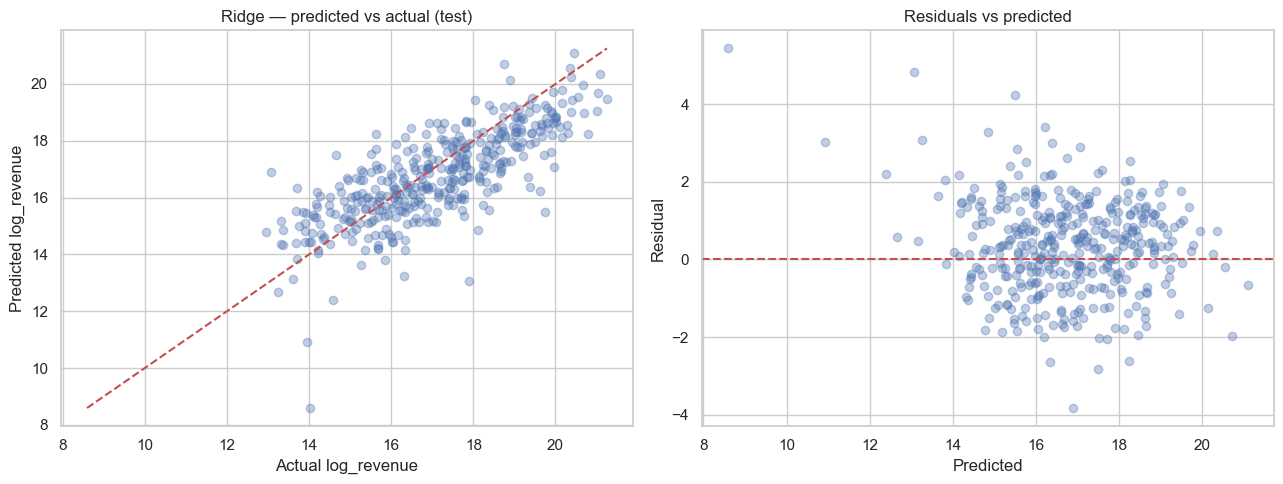

In [ ]:
#Regression plots
best_reg_name = reg_df.iloc[0]['model']
best_reg = reg_fitted[best_reg_name]
y_pred_test = best_reg.predict(X_test)
residuals   = y_reg_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_reg_test, y_pred_test, alpha=0.35)
lim = [min(y_reg_test.min(), y_pred_test.min()), max(y_reg_test.max(), y_pred_test.max())]
axes[0].plot(lim, lim, 'r--')
axes[0].set_xlabel('Actual log_revenue'); axes[0].set_ylabel('Predicted log_revenue')
axes[0].set_title(f'{best_reg_name} — predicted vs actual (test)')

axes[1].scatter(y_pred_test, residuals, alpha=0.35)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs predicted')
plt.tight_layout()
plt.savefig('model_outputs/02_regression_diagnostic.png', dpi=120)#save for the report
plt.show()

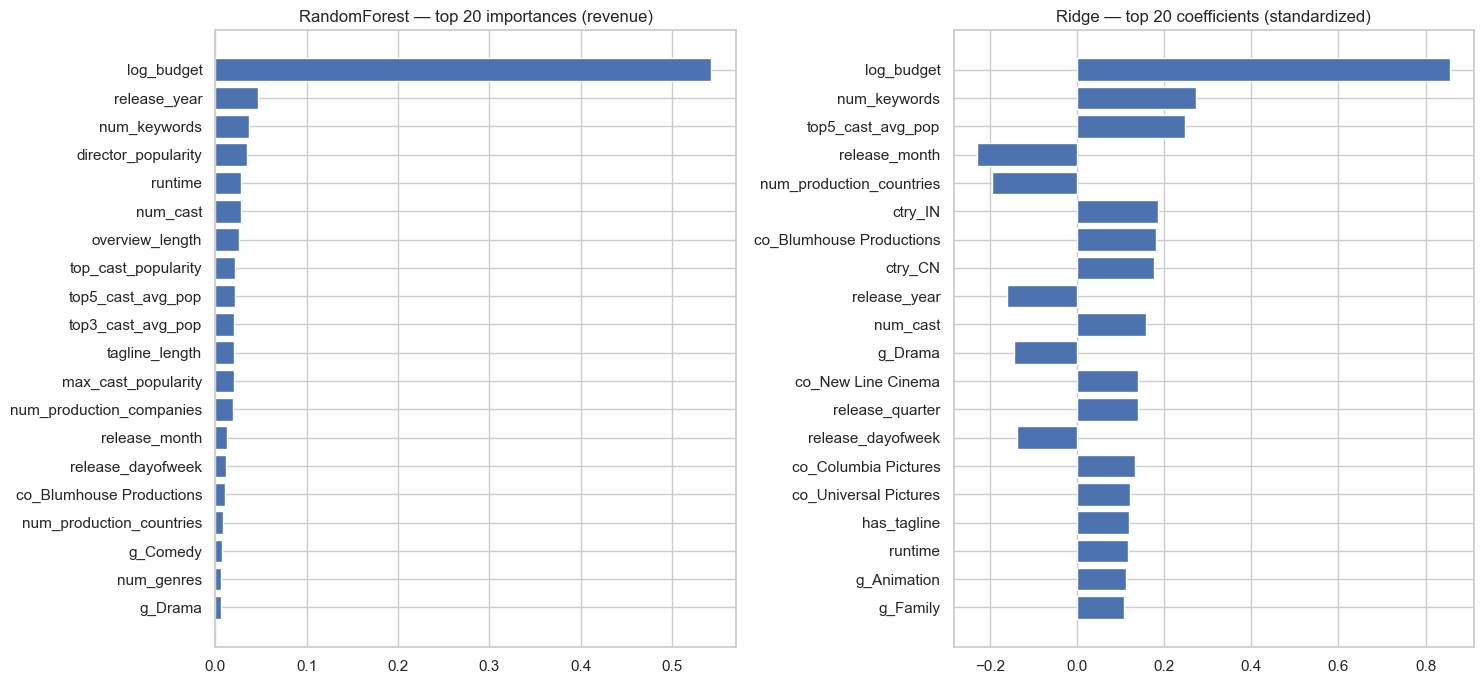

In [ ]:
#Regression feature importance
# Tree importance
rf_reg = reg_fitted['RandomForest']
imp = pd.DataFrame({'feature': FEATURES, 'importance': rf_reg.feature_importances_})
imp = imp.sort_values('importance', ascending=False)

#Linear coefficients
ridge = reg_fitted['Ridge'].named_steps['model']
coef = pd.DataFrame({'feature': FEATURES, 'coef': ridge.coef_})
coef['abs_coef'] = coef['coef'].abs()
coef = coef.sort_values('abs_coef', ascending=False)

#plot
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
top_imp = imp.head(20)
axes[0].barh(top_imp['feature'], top_imp['importance']); axes[0].invert_yaxis()
axes[0].set_title('RandomForest — top 20 importances (revenue)')
top_coef = coef.head(20)
axes[1].barh(top_coef['feature'], top_coef['coef']); axes[1].invert_yaxis()
axes[1].set_title('Ridge — top 20 coefficients (standardized)')
plt.tight_layout()
plt.savefig('model_outputs/03_regression_importance.png', dpi=120)
plt.show()

## 3. Task B — High-rating classification

Class imbalance ≈ 29% positives. We use `class_weight='balanced'` for linear and RF models.

In [ ]:
#Classification models
cls_models = {
    'Baseline_Majority': DummyClassifier(strategy='stratified', random_state=42),
    'LogReg': Pipeline([('scaler', StandardScaler()),
                        ('model', LogisticRegression(max_iter=2000, class_weight='balanced',
                                                     C=1.0, random_state=42))]),
    'RandomForest': RandomForestClassifier(n_estimators=400, max_depth=None, min_samples_leaf=2,
                                           class_weight='balanced', n_jobs=-1, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=400, max_depth=3, learning_rate=0.05,
                                                   random_state=42),
}

cls_results = []
cls_fitted  = {}
for name, m in cls_models.items():
    m.fit(X_train, y_cls_train)
    prob_val  = m.predict_proba(X_val)[:,  1]
    prob_test = m.predict_proba(X_test)[:, 1]
    val_metrics  = eval_classification(y_cls_val,  prob_val)
    test_metrics = eval_classification(y_cls_test, prob_test)
    cls_results.append({'model': name,
                        **{f'val_{k}': v  for k, v in val_metrics.items()},
                        **{f'test_{k}': v for k, v in test_metrics.items()}})
    cls_fitted[name] = m

cls_df = pd.DataFrame(cls_results).sort_values('test_ROC_AUC', ascending=False)
cls_df

,model,val_ROC_AUC,val_Accuracy,val_F1,val_PosRate,test_ROC_AUC,test_Accuracy,test_F1,test_PosRate
3,GradientBoosting,0.749545,0.698795,0.583333,0.325301,0.753577,0.702564,0.576642,0.361538
2,RandomForest,0.744242,0.686747,0.518519,0.253012,0.744185,0.697436,0.520325,0.289744
1,LogReg,0.760303,0.632530,0.643275,0.632530,0.725198,0.574359,0.589109,0.694872
0,Baseline_Majority,0.446061,0.493976,0.250000,0.277108,0.478277,0.553846,0.268908,0.269231


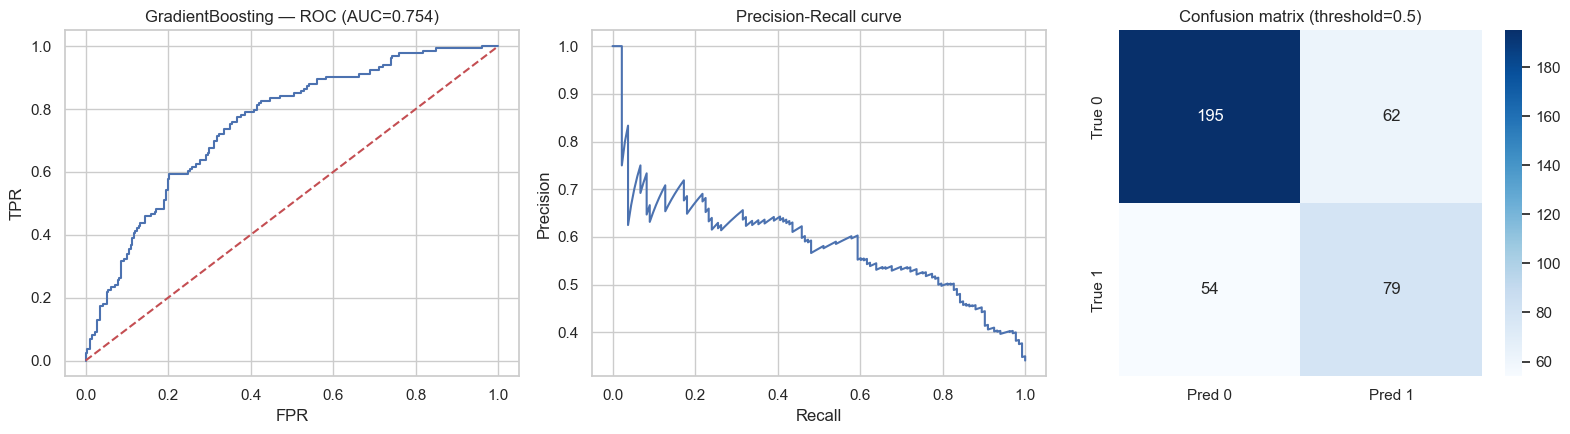

In [ ]:
#Classification results analysis
best_cls_name = cls_df.iloc[0]['model']
best_cls = cls_fitted[best_cls_name]
prob_test = best_cls.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_cls_test, prob_test)
prec, rec, _ = precision_recall_curve(y_cls_test, prob_test)
cm = confusion_matrix(y_cls_test, pred_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(fpr, tpr); axes[0].plot([0,1],[0,1],'r--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title(f'{best_cls_name} — ROC (AUC={roc_auc_score(y_cls_test, prob_test):.3f})')

axes[1].plot(rec, prec); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
axes[2].set_title('Confusion matrix (threshold=0.5)')
plt.tight_layout()
plt.savefig('model_outputs/05_classification_diagnostic.png', dpi=120)
plt.show()

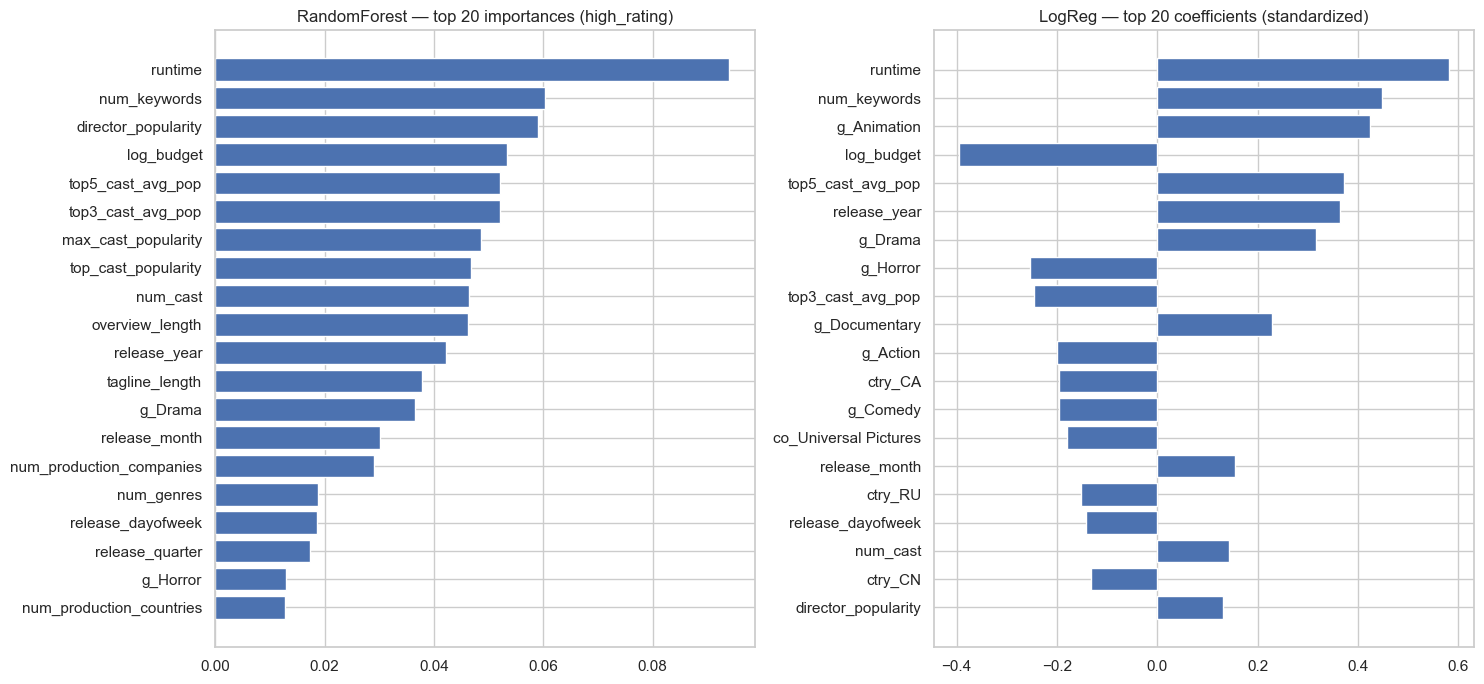

In [ ]:
#Classification feature importance & coefficients
rf_cls = cls_fitted['RandomForest']
cls_imp = pd.DataFrame({'feature': FEATURES, 'importance': rf_cls.feature_importances_})
cls_imp = cls_imp.sort_values('importance', ascending=False)

logreg = cls_fitted['LogReg'].named_steps['model']
cls_coef = pd.DataFrame({'feature': FEATURES, 'coef': logreg.coef_[0]})
cls_coef['abs_coef'] = cls_coef['coef'].abs()
cls_coef = cls_coef.sort_values('abs_coef', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
top_imp = cls_imp.head(20)
axes[0].barh(top_imp['feature'], top_imp['importance']); axes[0].invert_yaxis()
axes[0].set_title('RandomForest — top 20 importances (high_rating)')
top_coef = cls_coef.head(20)
axes[1].barh(top_coef['feature'], top_coef['coef']); axes[1].invert_yaxis()
axes[1].set_title('LogReg — top 20 coefficients (standardized)')
plt.tight_layout()
plt.savefig('model_outputs/06_classification_importance.png', dpi=120)
plt.show()

## 4. Error analysis

In [ ]:
#Regression error analysis: largest residuals on test
test_df = df_model.loc[test_mask, ['title','release_year','log_revenue']].copy()
test_df['pred_log_revenue'] = y_pred_test
test_df['residual'] = residuals
test_df['abs_residual'] = test_df['residual'].abs()

worst = test_df.sort_values('abs_residual', ascending=False).head(15)

# Residual by number of genres to probe heteroscedasticity
test_df['num_genres'] = df_model.loc[test_mask, 'num_genres'].values
resid_by_ng = test_df.groupby('num_genres')['abs_residual'].agg(['count','mean']).reset_index()
print('Worst cases (regression):')
worst

Worst cases (regression):


,title,release_year,log_revenue,pred_log_revenue,residual,abs_residual
6885,Scrapper,2023,14.026164,8.593962,5.432202,5.432202
7079,Life After Fighting,2024,17.901993,13.071565,4.830427,4.830427
7018,Limonov: The Ballad,2024,19.749142,15.504693,4.244449,4.244449
6977,The Kill Room,2023,13.073963,16.901536,-3.827573,3.827573
6520,Lost in the Stars,2023,19.626769,16.223145,3.403624,3.403624
7071,How to Make Millions Before Grandma Dies,2024,18.116869,14.846339,3.270531,3.270531
6679,His Only Son,2023,16.308716,13.248064,3.060652,3.060652
7470,Niki,2024,13.961452,10.931678,3.029774,3.029774
6527,TAYLOR SWIFT | THE ERAS TOUR,2023,19.382542,16.389463,2.993079,2.993079
7011,Pegasus 2,2024,19.961546,17.061683,2.899863,2.899863


In [ ]:
#Classification error analysis
test_cls_df = df_model.loc[test_mask, ['title','release_year','tmdb_vote_average','high_rating']].copy()
test_cls_df['prob_high'] = prob_test
test_cls_df['pred_high'] = pred_test
test_cls_df['error'] = (test_cls_df['pred_high'] != test_cls_df['high_rating']).astype(int)

false_pos = test_cls_df[(test_cls_df['pred_high']==1) & (test_cls_df['high_rating']==0)] \
                .sort_values('prob_high', ascending=False).head(10)
false_neg = test_cls_df[(test_cls_df['pred_high']==0) & (test_cls_df['high_rating']==1)] \
                .sort_values('prob_high').head(10)
print('High-confidence false positives:')
false_pos

High-confidence false positives:


,title,release_year,tmdb_vote_average,high_rating,prob_high,pred_high,error
7004,Wicked,2024,6.908,0,0.949227,1,1
6528,Wish,2023,6.219,0,0.936562,1,1
7304,Queer,2024,6.600,0,0.929555,1,1
7195,Megalopolis,2024,5.187,0,0.910030,1,1
6618,Noryang: Deadly Sea,2023,6.378,0,0.890253,1,1
7180,Kinds of Kindness,2024,6.502,0,0.889905,1,1
7162,The Lord of the Rings: The War of the Rohirrim,2024,6.548,0,0.885401,1,1
6548,Deep Sea,2023,6.990,0,0.842829,1,1
7109,The Best Christmas Pageant Ever,2024,6.900,0,0.835477,1,1
6759,Consent,2023,6.846,0,0.811336,1,1


## 5. Threshold tuning (classification)

Because positives are ~29%, the default 0.5 threshold may be suboptimal for F1.

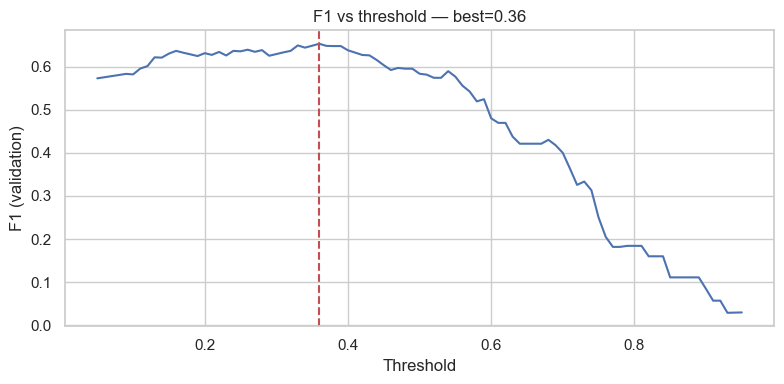

,model,best_threshold,ROC_AUC,Accuracy,F1,PosRate
0,GradientBoosting,0.36,0.753577,0.671795,0.619048,0.520513


In [ ]:
#Find F1-optimal threshold on validation, re-evaluate on test
prob_val_best = best_cls.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_cls_val, (prob_val_best >= t).astype(int)) for t in thresholds]
best_t = float(thresholds[int(np.argmax(f1s))])

test_metrics_tuned = eval_classification(y_cls_test, prob_test, threshold=best_t)
tuned_row = pd.DataFrame([{'model': best_cls_name, 'best_threshold': best_t, **test_metrics_tuned}])

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1s); plt.axvline(best_t, color='r', linestyle='--')
plt.xlabel('Threshold'); plt.ylabel('F1 (validation)')
plt.title(f'F1 vs threshold — best={best_t:.2f}')
plt.tight_layout()
plt.savefig('model_outputs/09_threshold_curve.png', dpi=120)
plt.show()
tuned_row